# Imports

In [28]:
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, accuracy_score, f1_score, confusion_matrix

# Constants & Configurations

In [29]:
TICKERS = ['AAPL', 'GOOG', 'MSFT', 'NVDA', 'JPM', 'GS', 'XOM', 'CAT', 'GE', 'WMT']
UNSEEN_TICKERS = ['TSLA', 'META', 'JPM']

In [30]:
# Model Configurations
INPUT_SIZE = 9
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.2

HUBER_LOSS_DELTA = 2.0

PRED_EPOCHS = 50
CLASS_EPOCHS = 50

BATCH_SIZE = 32
SHUFFLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Silver Transform Functions

In [31]:
# Defining transformation functions

# Simple Moving Average

def calculate_moving_average(dataframe, window):
    col_name = "".join(filter(str.isdigit, str(window)))

    dataframe[f"sma_{col_name}"] = (
        dataframe['Close']
        .rolling(window = window, min_periods = 1)
        .mean()
    )

    return dataframe; 

# RSI Calculations

def calculate_rsi(dataframe, window_size): 
    temp_df = pd.DataFrame({'Difference': dataframe['Close'].diff()})

    temp_df['Gain'] = temp_df['Difference'].clip(lower = 0)
    temp_df['Loss'] = temp_df['Difference'].clip(upper = 0).abs()

    temp_df['Avg_Gain'] = temp_df['Gain'].rolling(window = window_size, min_periods = 1).mean()
    temp_df['Avg_Loss'] = temp_df['Loss'].rolling(window = window_size, min_periods = 1).mean()

    rs = temp_df['Avg_Gain'] / temp_df['Avg_Loss']

    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'rsi_{col_name}'] = 100 - (100 / (1 + rs))

    return dataframe

def calculate_ewm_rsi(dataframe, window_size): 
    temp_df = pd.DataFrame({'Difference': dataframe['Close'].diff()})

    temp_df['Gain'] = temp_df['Difference'].clip(lower = 0)
    temp_df['Loss'] = temp_df['Difference'].clip(upper = 0).abs()

    temp_df['Avg_Gain'] = temp_df['Gain'].ewm(span = window_size, adjust = False).mean()
    
    temp_df['Avg_Loss'] = temp_df['Loss'].ewm(span = window_size, adjust = False).mean()

    rs = temp_df['Avg_Gain'] / temp_df['Avg_Loss']

    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'ewm_rsi_{col_name}'] = 100 - (100 / (1 + rs))

    return dataframe

# Volatility & Bollinger Bands
def calculate_volatility(dataframe, window_size): 
    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'volatility_{col_name}'] = dataframe['Close'].rolling(window = window_size, min_periods = 2).std()

    return dataframe

def calculate_bollinger_bands(dataframe, window_size, num_std): 
    roll_window = dataframe['Close'].rolling(window = window_size, min_periods = 2)

    mid_band = roll_window.mean()
    std_dev = roll_window.std()

    col_id = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'bollinger_band_mid_{col_id}'] = mid_band
    dataframe[f'bollinger_band_upper_{col_id}'] = mid_band + (num_std * std_dev)
    dataframe[f'bollinger_band_lower_{col_id}'] = mid_band - (num_std * std_dev)

    return dataframe

def transform(dataframe): 
    df = dataframe.sort_index().copy()
    
    df = calculate_moving_average(dataframe, 20)
    df = calculate_moving_average(dataframe, 50)
    df = calculate_moving_average(dataframe, 100)
    df = calculate_rsi(dataframe, 14)
    df = calculate_ewm_rsi(dataframe, 14)
    df = calculate_volatility(dataframe, 30)
    df = calculate_bollinger_bands(dataframe, 30, 2)

    return df

# Gold Transform Functions

In [32]:
def transform_gold(dataframe): 
    df = dataframe.copy()
    
    trimmed_df = df.drop(['High', 'Low', 'Open'], axis=1)
    
    # Assest that values match
    expected_columns = ['Close', 'Volume', 'sma_20', 'sma_50', 'sma_100',
                        'bollinger_band_upper_30', 'bollinger_band_lower_30',
                        'bollinger_band_mid_30', 'rsi_14', 'ewm_rsi_14', 'volatility_30']
    
    columns_to_drop = ['Close', 'Volume', 'sma_20', 'sma_50', 'sma_100', 'volatility_30', 
                        'day_of_week']
    
    is_match = set(trimmed_df.columns) == set(expected_columns)
    
    # Calculating target
    if not is_match:
        print("Columns do not match expected columns")
        return df
    
    trimmed_df['target'] = trimmed_df['Close'].pct_change(21)
    
    target_lower = trimmed_df["target"].quantile(0.01)
    target_upper = trimmed_df["target"].quantile(0.99)
    
    trimmed_df["target"] = trimmed_df["target"].clip(lower=target_lower, upper=target_upper)
    
    # Calculating Price Relative MA's
    trimmed_df['close_to_sma_20'] = (trimmed_df['Close'] / trimmed_df['sma_20']) - 1
    trimmed_df['close_to_sma_50'] = (trimmed_df['Close'] / trimmed_df['sma_50']) - 1
    
    # Calculating Bollinger Bands
    trimmed_df["pc_b"] = (trimmed_df['Close'] - trimmed_df["bollinger_band_lower_30"]) / (trimmed_df['bollinger_band_upper_30'] - trimmed_df['bollinger_band_lower_30'])
    trimmed_df["pc_b"] = trimmed_df["pc_b"].clip(lower=0, upper=1)
    
    trimmed_df['bb_width'] = (trimmed_df['bollinger_band_upper_30'] - trimmed_df['bollinger_band_lower_30']) / trimmed_df['bollinger_band_mid_30']
    trimmed_df = trimmed_df.drop(columns=['bollinger_band_upper_30', 'bollinger_band_lower_30', 'bollinger_band_mid_30'])
    
    # Calculating RSI
    threshold = 0.85
    correlation = trimmed_df[['rsi_14', 'ewm_rsi_14']].corr()
    
    corr_value = correlation.iloc[0, 1]
    
    if abs(corr_value) > threshold: 
        columns_to_drop.append('ewm_rsi_14')
        print(f"RSI Correlation: {corr_value:.3f} - Dropping ewm_rsi_14 {abs(corr_value)} > threshold (0.85)")
        
    # Calculating Volatility
    pct_returns_series = trimmed_df['Close'].pct_change()
    trimmed_df['pct_volatility_30'] = pct_returns_series.rolling(window=30, min_periods=30).std()
    
    # Calculating Volume
    volume_pct_change = trimmed_df["Volume"].pct_change()
    trimmed_df['volume_pct_change'] = volume_pct_change
    
    vol_lower = trimmed_df['volume_pct_change'].quantile(0.01)
    vol_upper = trimmed_df['volume_pct_change'].quantile(0.99)
    
    trimmed_df['volume_pct_change'] = trimmed_df['volume_pct_change'].clip(lower=vol_lower, upper=vol_upper)
    
    # Calculating Cyclical Day of the Week
    trimmed_df['day_of_week'] = trimmed_df.index.dayofweek
    
    trimmed_df['day_sin'] = np.sin(2 * np.pi * trimmed_df['day_of_week'] / 5)
    trimmed_df['day_cos'] = np.cos(2 * np.pi * trimmed_df['day_of_week'] / 5)
    
    # Cleaning up 
    processed_df = trimmed_df.drop(columns=columns_to_drop)
    
    processed_df = processed_df.dropna()
    
    return processed_df

# Build Datasets & Create Sequences Functions

In [33]:
def create_sequence(features, target, window_size): 
    X = []
    y = []
    
    for i in range (len(features) - window_size): 
        window = features[i: i + window_size]
        label = target[i + window_size]
        
        X.append(window)
        y.append(label)
    
    return np.array(X), np.array(y)

def build_dataset(tickers, window_size): 
    ticker_data = {}
    X_train_all = []
    target_data_all = []
    scaler = MinMaxScaler()
    
    for t in tickers: 
        df = yf.download(t, period="max", interval="1d")
        if isinstance(df.columns, pd.MultiIndex): 
            df.columns = df.columns.droplevel(1)
        
        print(f"Columns for {t}: {df.columns}")
        
        silver_df = transform(df)
        gold_df = transform_gold(silver_df)
        
        if gold_df is None or gold_df.empty: 
            print(f"{t} failed. Skipping...")
            continue
        
        train_end = int(len(gold_df) * .70)
        val_end = int(len(gold_df) * .85)
        
        train_df = gold_df.iloc[:train_end]
        val_df = gold_df.iloc[train_end:val_end]
        test_df = gold_df.iloc[val_end:]
        
        X_train = train_df.drop(columns=['target'])
        y_train = train_df['target'].values
        
        X_val = val_df.drop(columns=['target'])
        y_val = val_df['target'].values
        
        X_test = test_df.drop(columns=['target'])      
        y_test = test_df['target'].values
        
        ticker_data[t] = {
            'X_train': X_train.to_numpy(), 'X_val': X_val.to_numpy(), 'X_test': X_test.to_numpy(),
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test
        }
        
        X_train_all.append(X_train.to_numpy())
    
    X_train = np.concatenate(X_train_all)
    scaler.fit(X_train)
    
    X_train_seqs, X_val_seqs, X_test_seqs = [], [], []
    y_train_seqs, y_val_seqs, y_test_seqs = [], [], []
    
    for t, t_data in ticker_data.items(): 
        t_data['X_train'] = scaler.transform(t_data['X_train'])
        t_data['X_val'] = scaler.transform(t_data['X_val'])
        t_data['X_test'] = scaler.transform(t_data['X_test'])
        
        X_train_seq, y_train_seq = create_sequence(t_data['X_train'], t_data['y_train'], window_size)
        X_val_seq, y_val_seq = create_sequence(t_data["X_val"], t_data['y_val'], window_size)
        X_test_seq, y_test_seq = create_sequence(t_data['X_test'], t_data['y_test'], window_size)
        
        X_train_seqs.append(X_train_seq); X_val_seqs.append(X_val_seq); X_test_seqs.append(X_test_seq)
        y_train_seqs.append(y_train_seq); y_val_seqs.append(y_val_seq); y_test_seqs.append(y_test_seq)
    
    X_train = np.concatenate(X_train_seqs); X_val = np.concatenate(X_val_seqs); X_test = np.concatenate(X_test_seqs)
    y_train = np.concatenate(y_train_seqs); y_val = np.concatenate(y_val_seqs); y_test = np.concatenate(y_test_seqs)
    
    print(f"Before - mean: {y_train.mean():.6f} std: {y_train.std():.6f}")
    
    y_mean = y_train.mean()
    y_std = y_train.std()
    
    y_train_binary = (y_train > 0).astype(int)
    y_validate_binary = (y_val > 0).astype(int)
    y_test_binary = (y_test > 0).astype(int)
    
    y_train = (y_train - y_mean) / y_std
    y_val = (y_val - y_mean) / y_std
    y_test = (y_test - y_mean) / y_std
    
    print(f"After  - mean: {y_train.mean():.6f} std: {y_train.std():.6f}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, y_mean, y_std, y_train_binary, y_validate_binary, y_test_binary

# DataLoaders Construction

In [34]:
X_train, y_train, X_validate, y_validate, X_test, y_test, scaler, y_mean, y_std, y_train_binary, y_validate_binary, y_test_binary = build_dataset(TICKERS, 42)

[*********************100%***********************]  1 of 1 completed


Columns for AAPL: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.880 - Dropping ewm_rsi_14 0.8803388371259965 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


Columns for GOOG: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.869 - Dropping ewm_rsi_14 0.8687323207834088 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


...

Columns for CAT: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.869 - Dropping ewm_rsi_14 0.8690634464541254 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


Columns for GE: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.870 - Dropping ewm_rsi_14 0.8697425966762378 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


Columns for WMT: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.871 - Dropping ewm_rsi_14 0.8706747749594301 > threshold (0.85)
Before - mean: 0.016929 std: 0.093325
After  - mean: 0.000000 std: 1.000000


In [35]:
pred_train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
pred_validate_ds = TensorDataset(torch.tensor(X_validate, dtype=torch.float32), torch.tensor(y_validate, dtype=torch.float32))
pred_test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

class_train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_binary, dtype=torch.float32))
class_validate_ds = TensorDataset(torch.tensor(X_validate, dtype=torch.float32), torch.tensor(y_validate_binary, dtype=torch.float32))
class_test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_binary, dtype=torch.float32))

In [36]:
pred_train_dl = DataLoader(pred_train_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)
pred_validate_dl = DataLoader(pred_validate_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)
pred_test_dl = DataLoader(pred_test_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)

class_train_dl = DataLoader(class_train_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)
class_validate_dl = DataLoader(class_validate_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)
class_test_dl = DataLoader(class_test_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE)

# Model Class Creation

In [37]:
class StockLSTM(nn.Module): 
    def __init__(self, input_size, hidden_size, num_layers, dropout): 
        super(StockLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(32, 1)
        )
        
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                total = param.size(0)
                quarter = total // 4
                param.data[quarter:quarter*2] = 1.0
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        
        prediction = self.regressor(last_time_step)
        
        return prediction

# Helper Functions

In [38]:
def directional_accuracy(y_true, y_pred):
    true_direction = np.sign(y_true)
    pred_direction = np.sign(y_pred)
    
    return (true_direction == pred_direction).mean()

# Pred Training Loop

In [39]:
pred_model = StockLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
pred_criterion = nn.HuberLoss(delta = 2.0)
pred_optimizer = optim.Adam(pred_model.parameters(), lr=0.005, weight_decay=0.001)

pred_model.to(device)

StockLSTM(
  (lstm): LSTM(9, 32, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [40]:
pred_model.eval()
with torch.no_grad():
    sample_X = next(iter(pred_train_dl))[0].to(device)
    sample_pred = pred_model(sample_X)
    print(sample_pred.squeeze()[:10])

tensor([0.2920, 0.2910, 0.2828, 0.2795, 0.2855, 0.2908, 0.2899, 0.2835, 0.2812,
        0.2865], device='cuda:0')


In [41]:
pred_train_losses = []
pred_val_losses = []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pred_optimizer, mode='min', patience=3, factor=0.5
)

print(f"Target STD: {y_train.std()}")

for epoch in range(PRED_EPOCHS): 
    pred_model.train()
    train_loss = 0.0
    
    # Epoch Train
    for batch_X, batch_y in pred_train_dl: 
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        pred_optimizer.zero_grad()
        
        prediction = pred_model(batch_X)
        loss = pred_criterion(prediction.squeeze(), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pred_model.parameters(), max_norm=1.0)
        pred_optimizer.step()
        
        train_loss += loss.item()
    
    # Validation Phase
    pred_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in pred_validate_dl: 
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            prediction = pred_model(batch_X)
            loss = pred_criterion(prediction.squeeze(), batch_y.squeeze())
            val_loss += loss.item()
            
    # Epoch Summary
    avg_train = train_loss / len(pred_train_dl)
    avg_val = val_loss / len(pred_validate_dl)
    
    scheduler.step(avg_val)
    
    pred_train_losses.append(avg_train)
    pred_val_losses.append(avg_val)
    
    print(f"Epoch {epoch+1}/{PRED_EPOCHS} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")
    print(f"Current LR: {pred_optimizer.param_groups[0]['lr']}")
    

Target STD: 1.0
Epoch 1/50 | Train Loss: 0.192368 | Val Loss: 0.091729
Current LR: 0.005
Epoch 2/50 | Train Loss: 0.104641 | Val Loss: 0.071489
Current LR: 0.005
Epoch 3/50 | Train Loss: 0.086161 | Val Loss: 0.061181
Current LR: 0.005
Epoch 4/50 | Train Loss: 0.083218 | Val Loss: 0.059487
Current LR: 0.005
Epoch 5/50 | Train Loss: 0.079546 | Val Loss: 0.055014
Current LR: 0.005
Epoch 6/50 | Train Loss: 0.078844 | Val Loss: 0.057799
Current LR: 0.005
Epoch 7/50 | Train Loss: 0.079115 | Val Loss: 0.057052
Current LR: 0.005
Epoch 8/50 | Train Loss: 0.079293 | Val Loss: 0.056407
Current LR: 0.005
Epoch 9/50 | Train Loss: 0.080006 | Val Loss: 0.054731
Current LR: 0.005
Epoch 10/50 | Train Loss: 0.078807 | Val Loss: 0.057861
Current LR: 0.005
Epoch 11/50 | Train Loss: 0.078596 | Val Loss: 0.053363
Current LR: 0.005
Epoch 12/50 | Train Loss: 0.077653 | Val Loss: 0.052433
Current LR: 0.005
Epoch 13/50 | Train Loss: 0.076944 | Val Loss: 0.052781
Current LR: 0.005
Epoch 14/50 | Train Loss: 0.076

# Classification Training Loopp

In [42]:
up_months = y_train_binary.sum() / len(y_train_binary)
down_months = (1 - y_train_binary).sum() / len(y_train_binary)

print(f"Up Months: {up_months:.2%}")
print(f"Down Months: {down_months:.2%}")

Up Months: 57.12%
Down Months: 42.88%


In [43]:
pos_weight = (y_train_binary == 0).sum() / (y_train_binary == 1).sum()
print(pos_weight)

0.7508021625423058


In [44]:
pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32).to(device)
classification_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

In [45]:
class_model = StockLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
class_optimizer = optim.Adam(class_model.parameters(), lr=0.005, weight_decay=0.001)

class_model.to(device)

StockLSTM(
  (lstm): LSTM(9, 32, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [46]:
class_train_losses = []
class_val_losses = []

class_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    class_optimizer, mode='min', patience=3, factor=0.5
)

print(f"Target STD: {y_train.std()}")

for epoch in range(CLASS_EPOCHS): 
    class_model.train()
    train_loss = 0.0
    
    # Epoch Train
    for batch_X, batch_y in class_train_dl: 
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        class_optimizer.zero_grad()
        
        prediction = class_model(batch_X)
        loss = classification_criterion(prediction.squeeze(), batch_y)
        loss.backward()
        # Prevents exploding gradient issue because it clips gradient if their vector sum exceeds the threshold. 
        torch.nn.utils.clip_grad_norm_(class_model.parameters(), max_norm=1.0)
        class_optimizer.step()
        
        train_loss += loss.item()
    
    # Validation Phase
    class_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in class_validate_dl: 
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            prediction = class_model(batch_X)
            loss = classification_criterion(prediction.squeeze(), batch_y.squeeze())
            val_loss += loss.item()
            
    # Epoch Summary
    avg_train = train_loss / len(class_train_dl)
    avg_val = val_loss / len(class_validate_dl)
    
    class_scheduler.step(avg_val)
    
    class_train_losses.append(avg_train)
    class_val_losses.append(avg_val)
    
    print(f"Epoch {epoch+1}/{CLASS_EPOCHS} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")
    print(f"Current LR: {class_optimizer.param_groups[0]['lr']}")
    

Target STD: 1.0
Epoch 1/50 | Train Loss: 0.236579 | Val Loss: 0.186538
Current LR: 0.005
Epoch 2/50 | Train Loss: 0.192012 | Val Loss: 0.180467
Current LR: 0.005
Epoch 3/50 | Train Loss: 0.187143 | Val Loss: 0.178460
Current LR: 0.005
Epoch 4/50 | Train Loss: 0.184270 | Val Loss: 0.177645
Current LR: 0.005
Epoch 5/50 | Train Loss: 0.183289 | Val Loss: 0.176626
Current LR: 0.005
Epoch 6/50 | Train Loss: 0.183278 | Val Loss: 0.176707
Current LR: 0.005
Epoch 7/50 | Train Loss: 0.183121 | Val Loss: 0.175539
Current LR: 0.005
Epoch 8/50 | Train Loss: 0.182573 | Val Loss: 0.175813
Current LR: 0.005
Epoch 9/50 | Train Loss: 0.182329 | Val Loss: 0.176523
Current LR: 0.005
Epoch 10/50 | Train Loss: 0.182783 | Val Loss: 0.177641
Current LR: 0.005
Epoch 11/50 | Train Loss: 0.182538 | Val Loss: 0.175751
Current LR: 0.0025
Epoch 12/50 | Train Loss: 0.175788 | Val Loss: 0.170936
Current LR: 0.0025
Epoch 13/50 | Train Loss: 0.175672 | Val Loss: 0.171842
Current LR: 0.0025
Epoch 14/50 | Train Loss: 0.

# Evaluation

## Prediction Model Evaluation

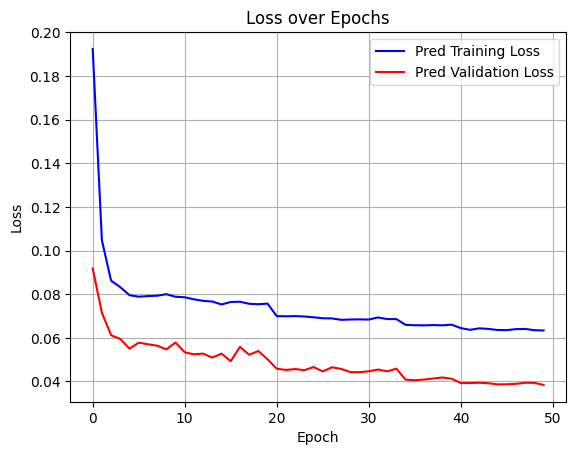

In [47]:
plt.plot(pred_train_losses, label="Pred Training Loss", color="blue")
plt.plot(pred_val_losses, label="Pred Validation Loss", color="Red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [51]:
pred_model.eval()

pred_all_predictions = []
pred_all_true = []

with torch.no_grad(): 
    for batch_X, batch_y in pred_test_dl: 
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        prediction = pred_model(batch_X)
        
        numpy_pred, numpy_y = prediction.detach(), batch_y.detach()
        
        pred_all_predictions.append(numpy_pred.squeeze().cpu().numpy())
        pred_all_true.append(batch_y.cpu().numpy())
        
pred_all_predictions = np.concatenate(pred_all_predictions, axis=0)
pred_all_true = np.concatenate(pred_all_true, axis=0)

In [52]:
mse  = mean_squared_error(pred_all_true, pred_all_predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(pred_all_true, pred_all_predictions)
da   = directional_accuracy(pred_all_true, pred_all_predictions)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"Directional Accuracy: {da:.2%}")

print(f"Prediction mean: {pred_all_predictions.mean():.6f}")
print(f"Prediction std:  {pred_all_predictions.std():.6f}")
print(f"Actual mean:     {pred_all_true.mean():.6f}")
print(f"Actual std:      {pred_all_true.std():.6f}")

RMSE: 0.314082
MAE:  0.224129
Directional Accuracy: 90.80%
Prediction mean: 0.034684
Prediction std:  0.786672
Actual mean:     0.062495
Actual std:      0.918693


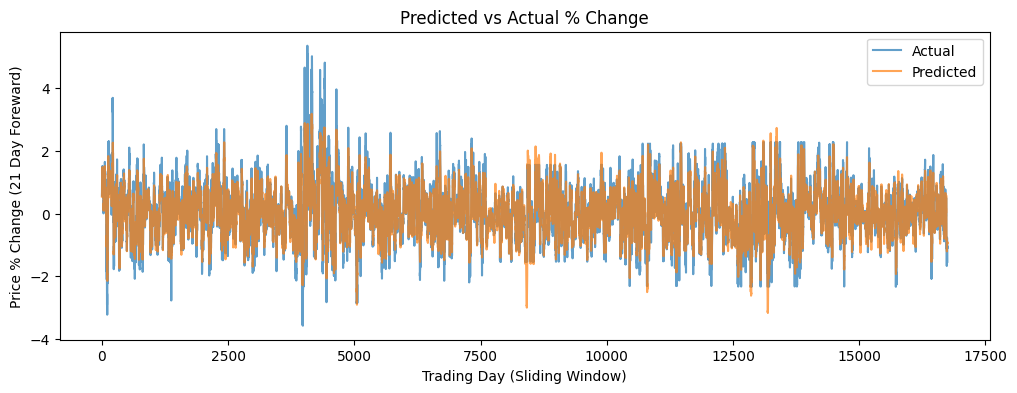

In [53]:
plt.figure(figsize=(12, 4))
plt.plot(pred_all_true, label='Actual', alpha=0.7)
plt.plot(pred_all_predictions, label='Predicted', alpha=0.7)
plt.xlabel("Trading Day (Sliding Window)")
plt.ylabel("Price % Change (21 Day Foreward)")
plt.legend()
plt.title('Predicted vs Actual % Change')
plt.show()

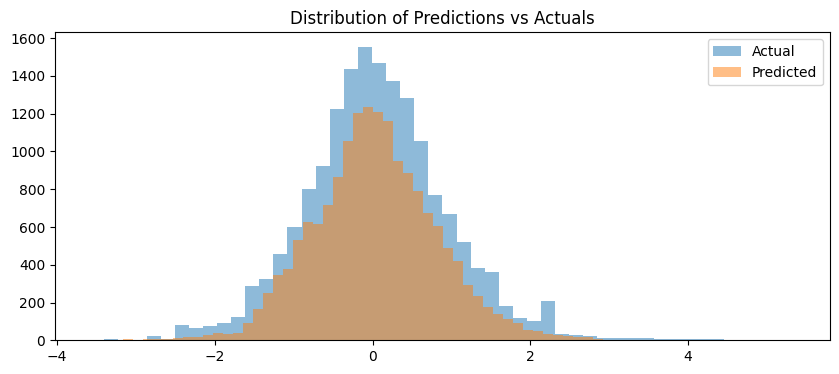

In [54]:
plt.figure(figsize=(10, 4))
plt.hist(pred_all_true, bins=50, alpha=0.5, label='Actual')
plt.hist(pred_all_predictions, bins=50, alpha=0.5, label='Predicted')
plt.legend()
plt.title('Distribution of Predictions vs Actuals')
plt.show()

# Classifier Model Evaluation

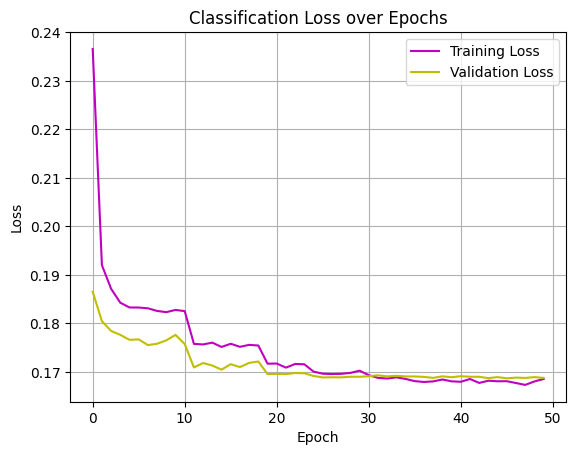

In [55]:
plt.plot(class_train_losses, label="Training Loss", color="m")
plt.plot(class_val_losses, label="Validation Loss", color="y")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss over Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [56]:
class_model.eval()

class_all_predictions = []
class_all_trues = []

with torch.no_grad(): 
    for batch_X, batch_y in class_test_dl: 
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        prediction = class_model(batch_X)
        
        probability = torch.sigmoid(prediction)
        predicted_class = (probability > 0.5).float()
        
        numpy_pred, numpy_y = prediction.detach(), batch_y.detach()
        
        class_all_predictions.append(predicted_class.cpu().numpy().flatten())
        class_all_trues.append(batch_y.cpu().numpy().flatten())
        
class_all_predictions = np.concatenate(class_all_predictions, axis=0)
class_all_trues = np.concatenate(class_all_trues, axis=0)

accuracy = accuracy_score(class_all_trues, class_all_predictions)
f1 = f1_score(class_all_trues, class_all_predictions)

print(f"Accuracy: {accuracy:.2%}")
print(f"F1 Score: {f1:.4f}")
print(classification_report(class_all_trues, class_all_predictions, target_names=['Down', 'Up']))

Accuracy: 91.77%
F1 Score: 0.9318
              precision    recall  f1-score   support

        Down       0.89      0.91      0.90      6563
          Up       0.94      0.92      0.93     10187

    accuracy                           0.92     16750
   macro avg       0.91      0.92      0.91     16750
weighted avg       0.92      0.92      0.92     16750



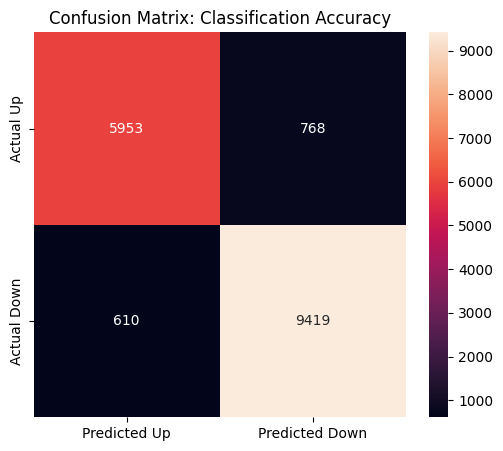

In [57]:
cm = confusion_matrix(class_all_predictions, class_all_trues)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="rocket", 
            xticklabels=["Predicted Up", "Predicted Down"], 
            yticklabels=["Actual Up", "Actual Down"]
)

plt.title("Confusion Matrix: Classification Accuracy")
plt.show()

# Inference Functions

In [81]:
def predict_next_month(ticker, pred_model, scaler, y_mean, y_std, window_size=42):
    df = yf.download(ticker, period="1y", interval="1d")
    df.columns = df.columns.droplevel(1)
    
    silver_df = transform(df)
    gold_df = transform_gold(silver_df)
    
    last_window = gold_df.drop(columns=['target']).tail(window_size).values
    last_window_scaled = scaler.transform(last_window)
    
    tensor = torch.tensor(last_window_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_model.eval()
    with torch.no_grad():
        prediction_standardized = pred_model(tensor).squeeze().item()
        
    prediction_pct = (prediction_standardized * y_std) + y_mean
    
    return prediction_pct
    
def predict_buy_signal(ticker, pred_model, class_model, scaler, y_mean, y_std, prob_threshold=0.65, magnitude_threshold=0.03, window_size=42):
    df = yf.download(ticker, period="1y", interval="1d")
    df.columns = df.columns.droplevel(1)
    
    silver_df = transform(df)
    gold_df = transform_gold(silver_df)
    
    last_window = gold_df.drop(columns=['target']).tail(window_size).values
    last_window_scaled = scaler.transform(last_window)
    
    tensor = torch.tensor(last_window_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_model.eval()
    with torch.no_grad(): 
        prediction_standardized = pred_model(tensor).squeeze().item()
    prediction_pct = (prediction_standardized * y_std) + y_mean
    
    class_model.eval()
    with torch.no_grad():
        class_prediction = class_model(tensor).squeeze().cpu()
    probability = torch.sigmoid(class_prediction).item()
    
    if probability > prob_threshold and prediction_pct > magnitude_threshold:
        signal = "BUY"
    elif probability < (1 - prob_threshold) and prediction_pct < -magnitude_threshold:
        signal = "SELL"
    else:
        signal = "HOLD"
    
    return {
        'ticker':      ticker,
        'magnitude':   f"{(prediction_pct * 100):.2f}%",
        'direction':   'UP' if probability > 0.5 else 'DOWN',
        'confidence':  f"{max(probability, 1-probability) * 100:.2f}%",
        'signal':      signal
    }

In [82]:
test_output = predict_buy_signal("MSFT", pred_model, class_model, scaler, y_mean, y_std)

[*********************100%***********************]  1 of 1 completed

RSI Correlation: 0.898 - Dropping ewm_rsi_14 0.8977104352712624 > threshold (0.85)


In [83]:
print(test_output)

{'ticker': 'MSFT', 'magnitude': '-8.31%', 'direction': 'DOWN', 'confidence': '98.76%', 'signal': 'SELL'}
